In [72]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import colors
from matplotlib.image import imread
import subprocess

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial'],
    'font.size':          8,
    'axes.labelsize':     8,
    'xtick.labelsize':    8,
    'ytick.labelsize':    8,
    'legend.fontsize':    8,
    'figure.titlesize':   8,
    'figure.dpi':         300,
    'savefig.dpi':        1000,
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'xtick.top':          False,
    'ytick.right':        False,
})

def inter_from_256(x):
    return np.interp(x=x, xp=[0,255], fp=[0,1])

cdict = {
    'red':  ((0.0,         inter_from_256(255), inter_from_256(255)),
             (1/350*90,    inter_from_256(0),   inter_from_256(0)),
             (1/350*265,   inter_from_256(230), inter_from_256(230)),
             (1/350*350,   inter_from_256(255), inter_from_256(255))),
    'green':((0.0,         inter_from_256(255), inter_from_256(255)),
             (1/350*90,    inter_from_256(0),   inter_from_256(0)),
             (1/350*265,   inter_from_256(86),  inter_from_256(86)),
             (1/350*350,   inter_from_256(128), inter_from_256(128))),
    'blue': ((0.0,         inter_from_256(255), inter_from_256(255)),
             (1/350*90,    inter_from_256(128), inter_from_256(128)),
             (1/350*265,   inter_from_256(102), inter_from_256(102)),
             (1/350*350,   inter_from_256(0),   inter_from_256(0))),
}
new_cmap = colors.LinearSegmentedColormap('new_cmap', segmentdata=cdict)

In [73]:
data_path = "/Users/tommychin/Library/CloudStorage/OneDrive-ThePennsylvaniaStateUniversity/SiV research/data/"

def load_amp(fname):
    d = np.load(data_path + fname)
    d = np.abs(d)
    d /= np.max(d)
    return d

unstrained  = load_amp("unstrained.npy")   # 4001x4001
rand6       = load_amp("rand6.npy")        # 500x500
I_uniDir    = load_amp("uniDir.npy")       # 500x500
I_uniDir_p0 = load_amp("uniDir_p0.npy")   # 500x500
I_randDir   = load_amp("randDir.npy")      # 500x500
I_iso       = load_amp("iso.npy")          # 500x500

In [74]:
Delta_ZPL_0  = 406.83
lambda_SO_gs = 46e-3
lambda_SO_es = 255e-3
center = Delta_ZPL_0 - lambda_SO_es + lambda_SO_gs  # 406.621 THz

# Unstrained: already cropped to Delta_ZPL_0 ± 0.5
nu_t_4001 = np.linspace(Delta_ZPL_0 - 0.5, Delta_ZPL_0 + 0.5, 4001)
EXTENT_4001 = (nu_t_4001[0], nu_t_4001[-1], -nu_t_4001[-1], -nu_t_4001[0])

# 500x500: full ±3 THz window around center, no cropping
nu_t_500   = np.linspace(center - 3, center + 3, 500)
nu_tau_500 = np.linspace(-(center + 3), -(center - 3), 500)
EXTENT_500 = (nu_t_500[0], nu_t_500[-1], nu_tau_500[0], nu_tau_500[-1])

In [75]:
def single_plot(Z, nu_t, extent, title, fname=None,
                overlay=None, overlay_nu_t=None,
                tick_spacing=1, tick_fmt='%.0f',
                line_color='r'):
    x = np.sum(Z, axis=0)
    x /= max(x)

    fig, ax = plt.subplots(figsize=(3.375, 4.5))
    im = ax.imshow(Z, origin='lower', extent=extent,
                   cmap=new_cmap, vmin=0, vmax=1, aspect='equal')

    divider  = make_axes_locatable(ax)
    axbottom = divider.append_axes("bottom", size="25%", pad=0.05, sharex=ax)
    cax      = divider.append_axes("right",  size="5%",  pad=0.05)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cbar.set_ticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0'])
    cax.set_ylabel('Amplitude (arb. units)', rotation=270, labelpad=10)

    if overlay is not None:
        ov = np.sum(overlay, axis=0)
        ov /= max(ov)
        axbottom.plot(overlay_nu_t, ov, 'r-', label='unstrained')

    axbottom.plot(nu_t, x, line_color, label='strained')

    if overlay is not None:
        axbottom.legend(loc='upper right', bbox_to_anchor=(1.2, 1.125), framealpha=0)

    axbottom.set_xlabel(r'Third-order frequency, $\nu_t$ (THz)')
    axbottom.set_ylim(0, 1)
    axbottom.set_yticks([0, 0.5, 1])
    axbottom.margins(x=0)
    axbottom.spines['top'].set_visible(False)
    axbottom.spines['right'].set_visible(False)
    axbottom.xaxis.set_major_locator(plt.MultipleLocator(tick_spacing))
    axbottom.xaxis.set_major_formatter(plt.FormatStrFormatter(tick_fmt))

    ax.xaxis.set_visible(True)
    ax.xaxis.set_ticks_position('bottom')
    plt.setp(ax.get_xticklabels(), visible=False)
    ax.xaxis.set_major_locator(plt.MultipleLocator(tick_spacing))
    ax.set_ylabel(r'First-order frequency, $\nu_\tau$ (THz)')
    ax.set_title(title, pad=4)
    ax.yaxis.set_major_locator(plt.MultipleLocator(tick_spacing))
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter(tick_fmt))

    plt.tight_layout()
    if fname:
        plt.savefig(fname, bbox_inches='tight', pad_inches=0.05)
    plt.show()
    return fig

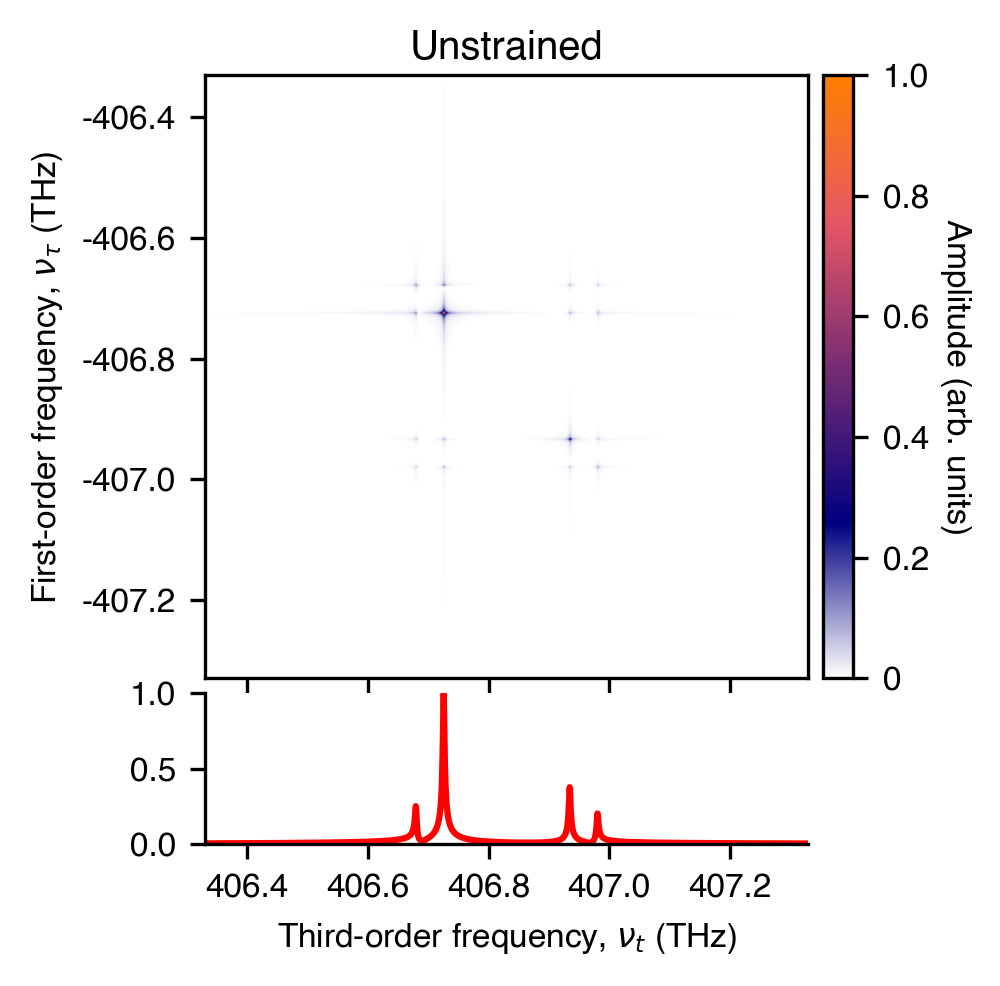

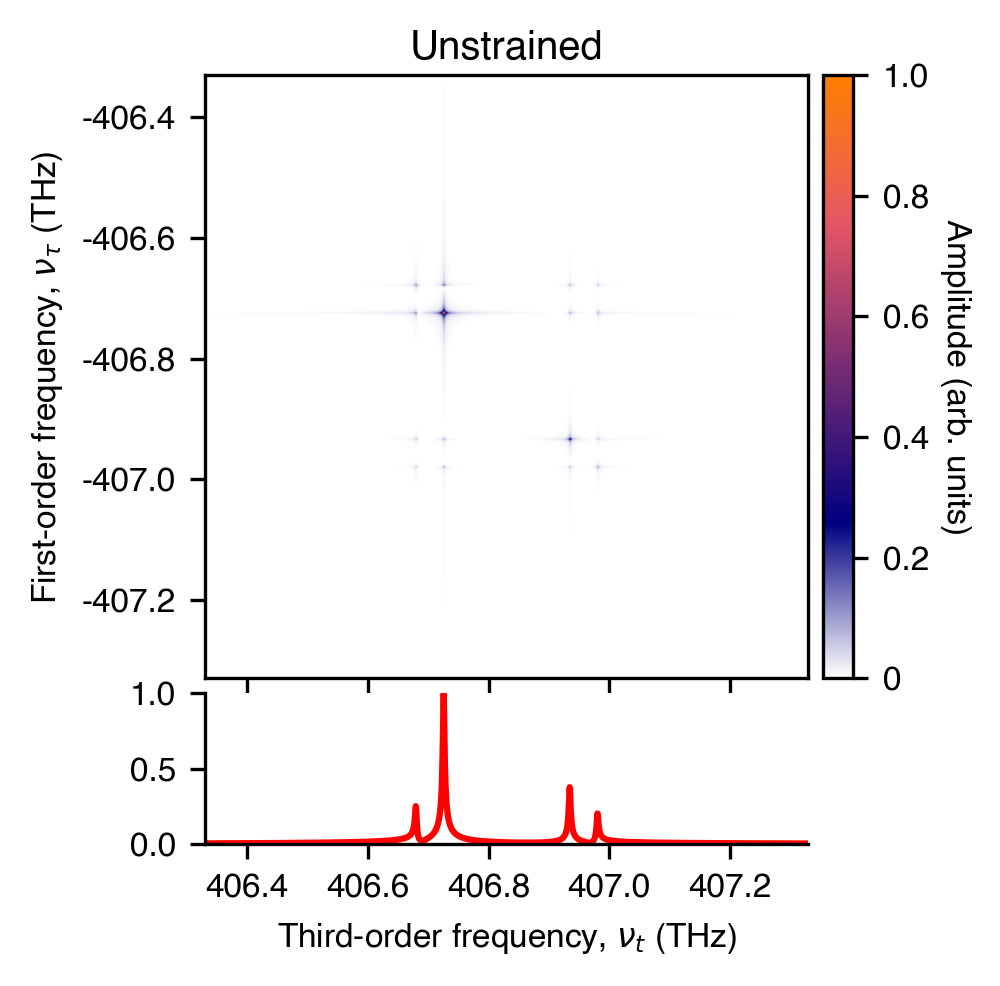

In [76]:
single_plot(np.abs(unstrained), nu_t_4001, extent=EXTENT_4001,
            title=r'Unstrained',
            tick_spacing=0.2, tick_fmt='%.1f',
            line_color='r',
            fname='Fig_unstrained.pdf')

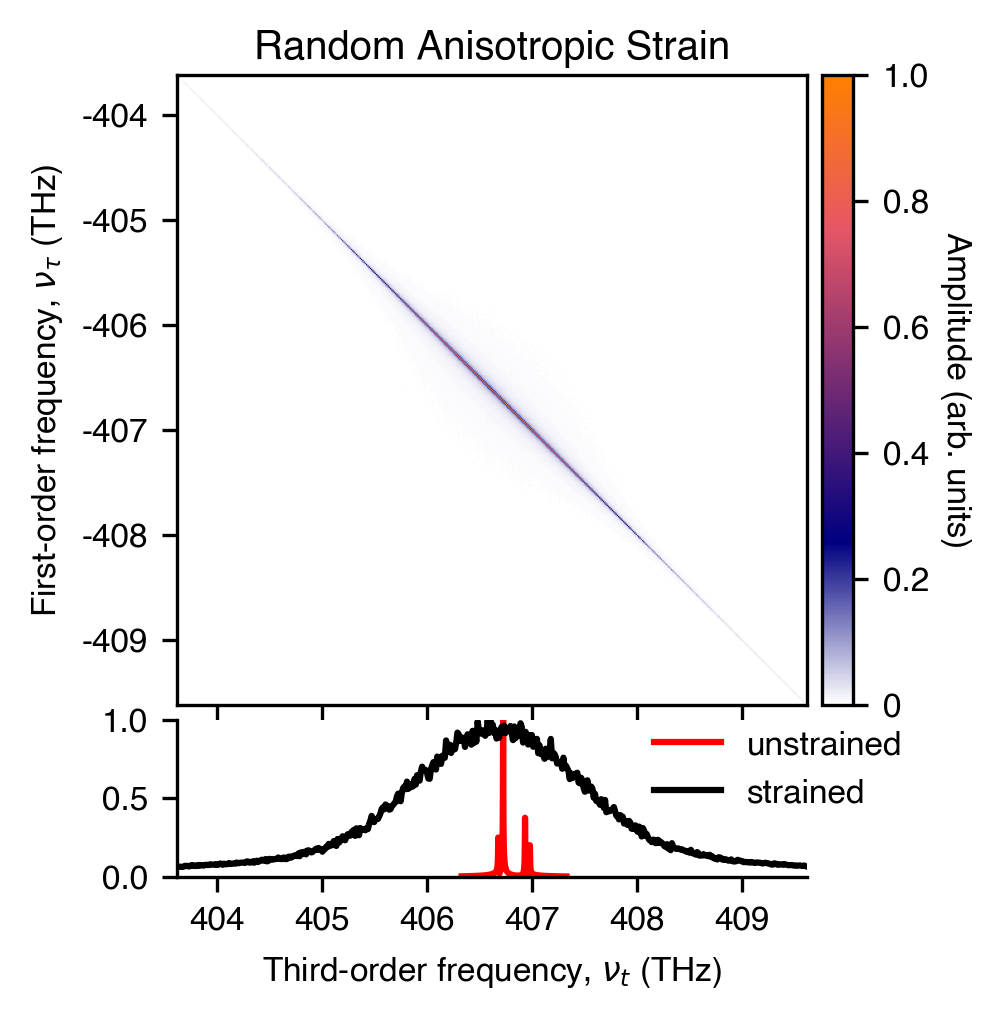

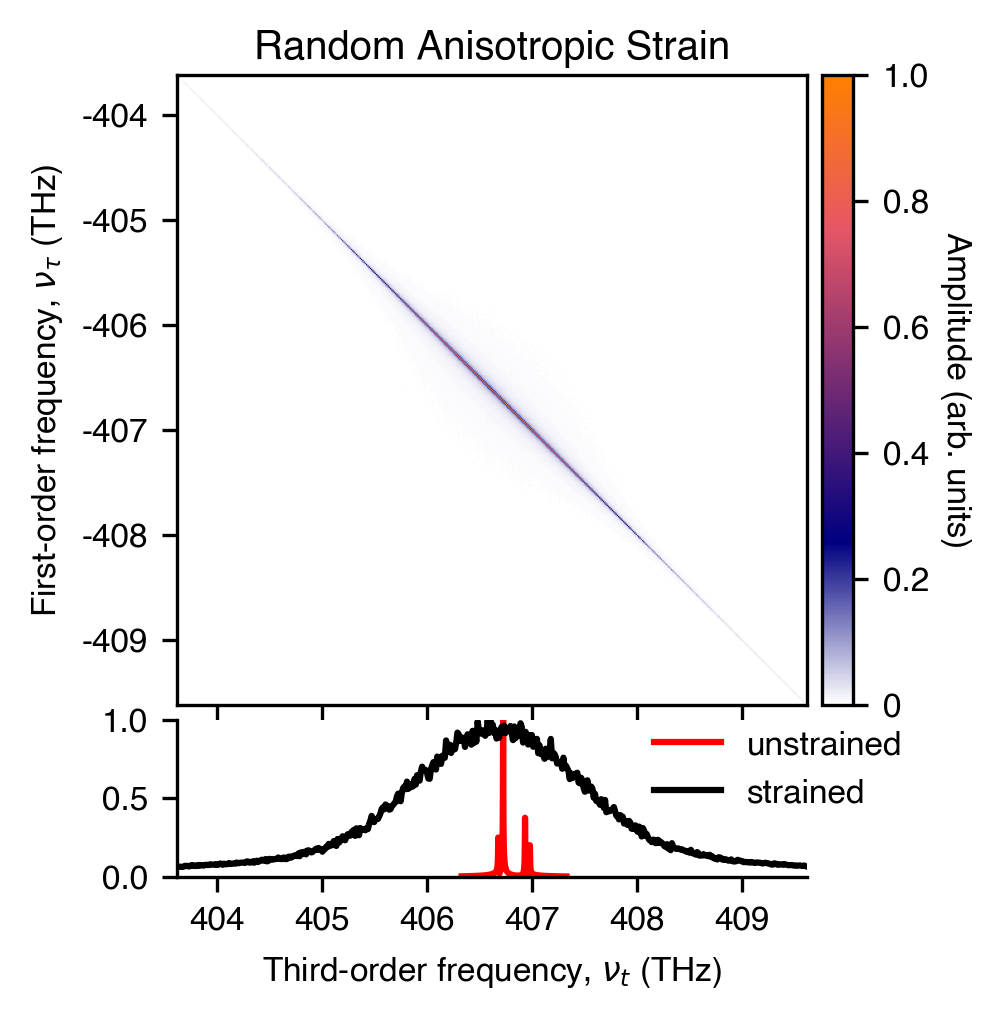

In [77]:
single_plot(np.abs(rand6), nu_t_500, extent=EXTENT_500,
            title=r'Random Anisotropic Strain',
            overlay=np.abs(unstrained), overlay_nu_t=nu_t_4001,
            tick_spacing=1, tick_fmt='%.0f',
            line_color='k',
            fname='Fig_rand6.pdf')

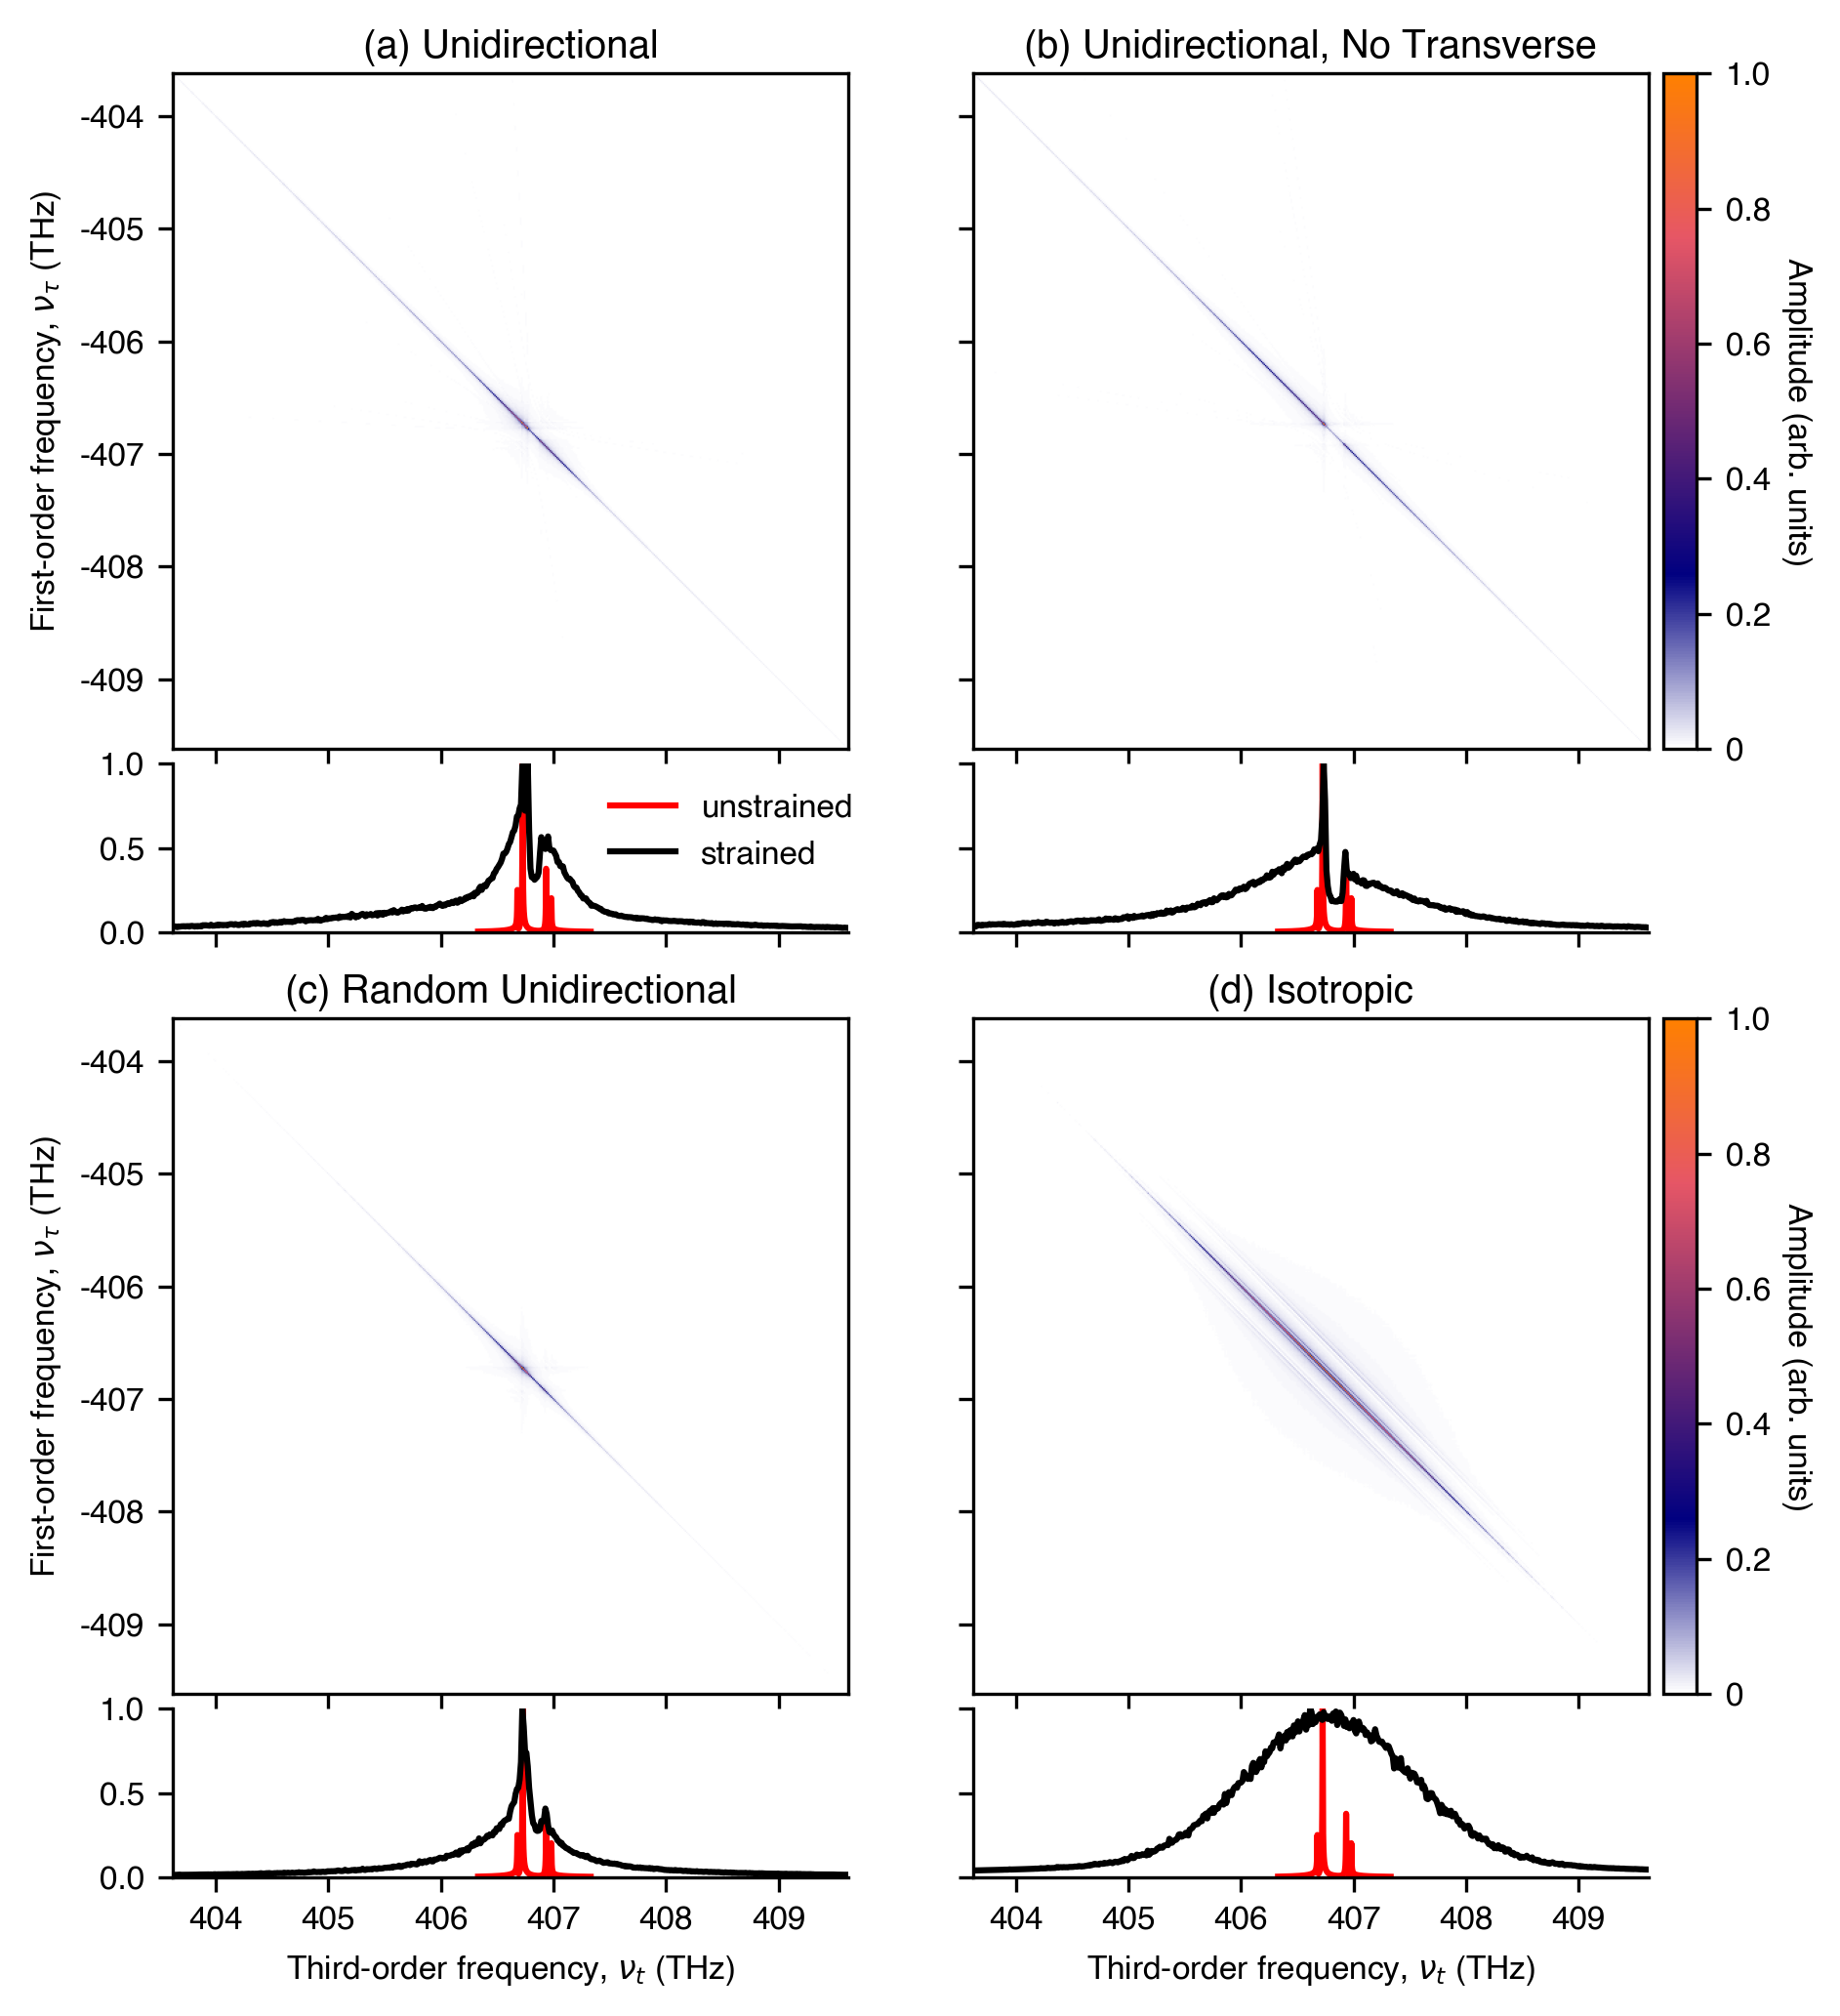

In [78]:
databox = [I_uniDir, I_uniDir_p0, I_randDir, I_iso]
titles  = [r'(a) Unidirectional',
           r'(b) Unidirectional, No Transverse',
           r'(c) Random Unidirectional',
           r'(d) Isotropic']

unstrained_x = np.sum(np.abs(unstrained), axis=0)
unstrained_x /= max(unstrained_x)

fig = plt.figure(figsize=(7.05, 8.0))
outer = gridspec.GridSpec(2, 2, wspace=0.0, hspace=0.1)

axes_2d  = []
axes_bot = []
images   = []

for i, (Z, title) in enumerate(zip(databox, titles)):
    x = np.sum(Z, axis=0)
    x /= max(x)

    row, col = i // 2, i % 2

    ax = plt.Subplot(fig, outer[i])
    im = ax.imshow(Z, origin='lower', extent=EXTENT_500,
                   cmap=new_cmap, vmin=0, vmax=1, aspect='equal')
    images.append(im)

    divider  = make_axes_locatable(ax)
    axbottom = divider.append_axes("bottom", size="25%", pad=0.05, sharex=ax)
    cax      = divider.append_axes("right",  size="5%",  pad=0.05)

    # colorbar only on right column
    if col == 1:
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        cbar.set_ticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0'])
        cax.set_ylabel('Amplitude (arb. units)', rotation=270, labelpad=10)
    else:
        cax.set_visible(False)

    # projection lines
    axbottom.plot(nu_t_4001, unstrained_x, 'r-', label='unstrained')
    axbottom.plot(nu_t_500, x, 'k-', label='strained')
    axbottom.set_ylim(0, 1)
    axbottom.set_yticks([0, 0.5, 1])
    axbottom.margins(x=0)
    axbottom.spines['top'].set_visible(False)
    axbottom.spines['right'].set_visible(False)
    axbottom.xaxis.set_major_locator(plt.MultipleLocator(1))
    axbottom.xaxis.set_major_formatter(plt.FormatStrFormatter('%.0f'))

    # x axis: only bottom row shows numbers, but all show the line
    if row == 0:
        plt.setp(axbottom.get_xticklabels(), visible=False)
    else:
        axbottom.set_xlabel(r'Third-order frequency, $\nu_t$ (THz)')

    # y axis: only left column shows numbers, but all show the line
    if col == 1:
        plt.setp(ax.get_yticklabels(), visible=False)
        plt.setp(axbottom.get_yticklabels(), visible=False)
    else:
        ax.set_ylabel(r'First-order frequency, $\nu_\tau$ (THz)')
        ax.yaxis.set_major_locator(plt.MultipleLocator(1))
        ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.0f'))

    ax.xaxis.set_visible(True)
    ax.xaxis.set_ticks_position('bottom')
    plt.setp(ax.get_xticklabels(), visible=False)
    ax.xaxis.set_major_locator(plt.MultipleLocator(1))
    ax.set_title(title, pad=4)

    if i == 0:
        axbottom.legend(loc='upper right', bbox_to_anchor=(1.05, 1.), framealpha=0)

    axes_2d.append(ax)
    axes_bot.append(axbottom)
    fig.add_subplot(ax)

plt.savefig('Fig_othermodels.pdf', bbox_inches='tight')
plt.show()